In [1]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
import seaborn as sns
import json

Carregando os resultados

In [2]:
with open('results/round1/ML_metrics.json', 'r') as f:
    metrics_per_iteration = json.load(f)

In [3]:
with open('results/round1/OACE_metrics.json', 'r') as f:
    oace_metrics_per_iteration = json.load(f)

Qual a correlação da lr com a assertividade e os custos dos modelos?

In [4]:
df = pd.DataFrame.from_dict(oace_metrics_per_iteration, orient='index')
df['lr'] = df['solution'].apply(lambda x: x['lr'])
df = df[['model_name', 'A', 'C', 'lr']]

In [17]:
df.describe()

,A,C,lr
count,150.000000,150.000000,150.000000
mean,0.546015,0.724152,0.005515
std,0.394237,0.325575,0.002376
min,0.000000,0.188394,0.002161
25%,0.092180,0.188394,0.002852
50%,0.759815,0.861377,0.005943
75%,0.921083,0.967202,0.007249
max,1.000000,1.000000,0.010000


In [21]:
for model in df['model_name'].unique():
    
    subset = df[df['model_name'] == model]
    print(f"Model: {model}")
    print(subset.describe())

Model: EfficientNetB0
               A          C         lr
count  25.000000  25.000000  25.000000
mean    0.285560   0.966180   0.005258
std     0.321139   0.002509   0.002251
min     0.000000   0.961728   0.002415
25%     0.086176   0.964784   0.002644
50%     0.123846   0.966208   0.005210
75%     0.380088   0.967146   0.007239
max     0.933661   0.972604   0.009812
Model: InceptionV3
               A          C         lr
count  31.000000  31.000000  31.000000
mean    0.967209   0.815106   0.005158
std     0.020929   0.005771   0.002403
min     0.931124   0.793859   0.002288
25%     0.952387   0.811856   0.002789
50%     0.965958   0.814700   0.004862
75%     0.984505   0.819681   0.006828
max     1.000000   0.823977   0.009803
Model: MobileNetV2
               A          C         lr
count  32.000000  32.000000  32.000000
mean    0.576560   0.999755   0.005570
std     0.328278   0.000449   0.002552
min     0.000000   0.998303   0.002325
25%     0.222726   0.999687   0.002919
50% 

Modelo: EfficientNetB0
Correlação (lr vs A): -0.71
Correlação (lr vs C): 0.25


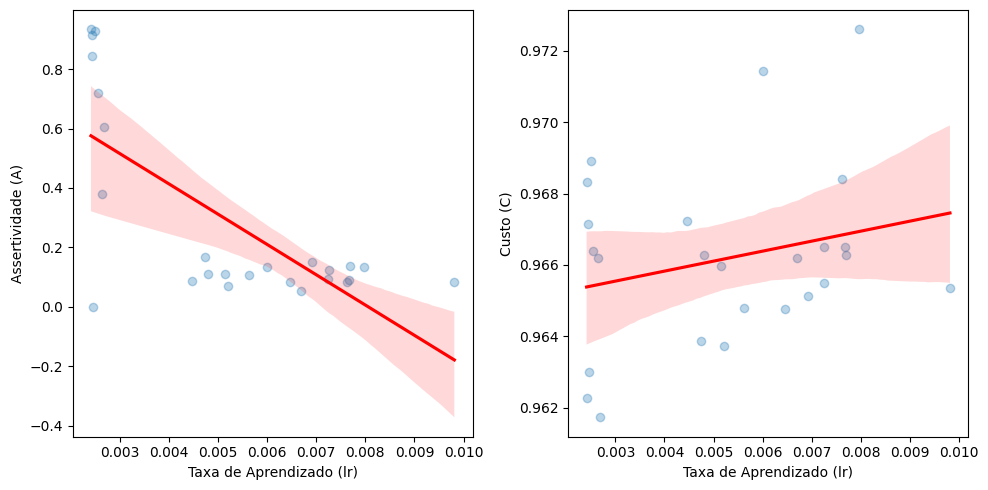

Modelo: InceptionV3
Correlação (lr vs A): -0.78
Correlação (lr vs C): 0.15


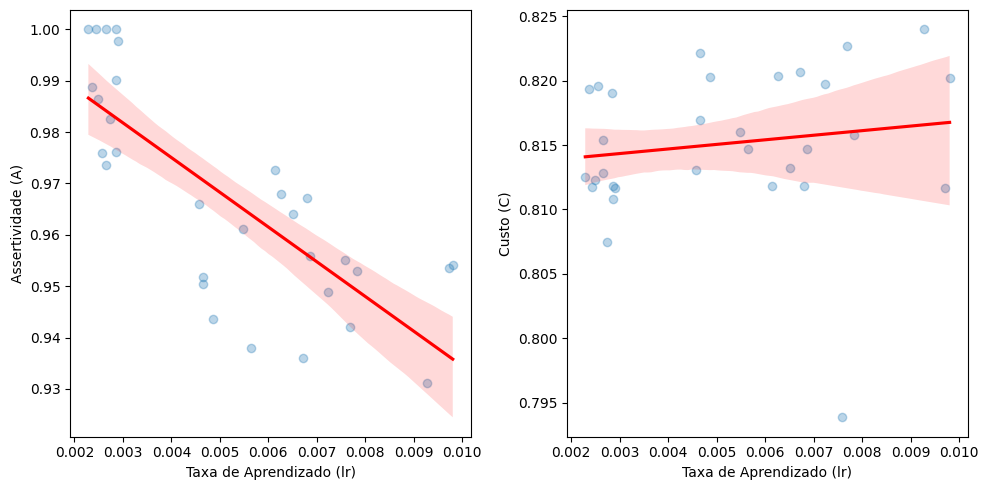

Modelo: MobileNetV2
Correlação (lr vs A): 0.76
Correlação (lr vs C): 0.40


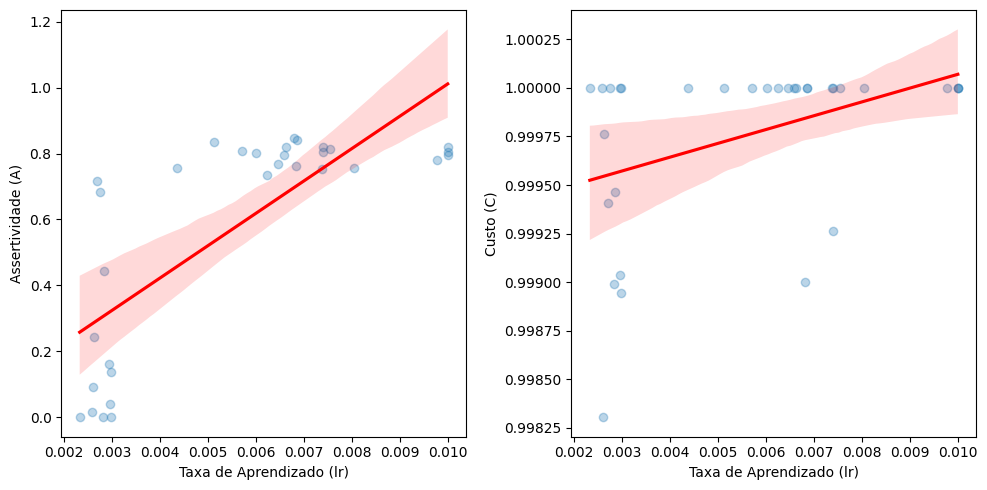

Modelo: VGG16
Correlação (lr vs A): -0.59
Correlação (lr vs C): 0.00


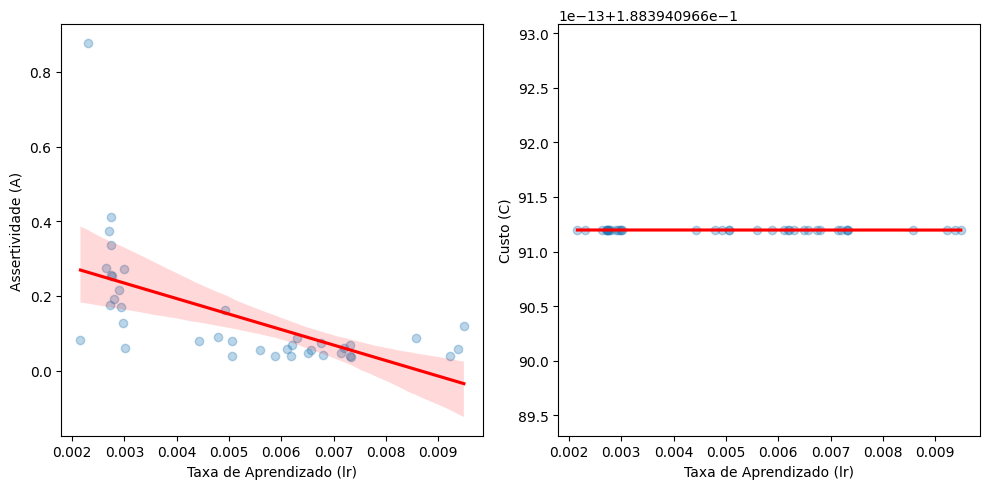

Modelo: ResNet50
Correlação (lr vs A): -0.60
Correlação (lr vs C): 0.76


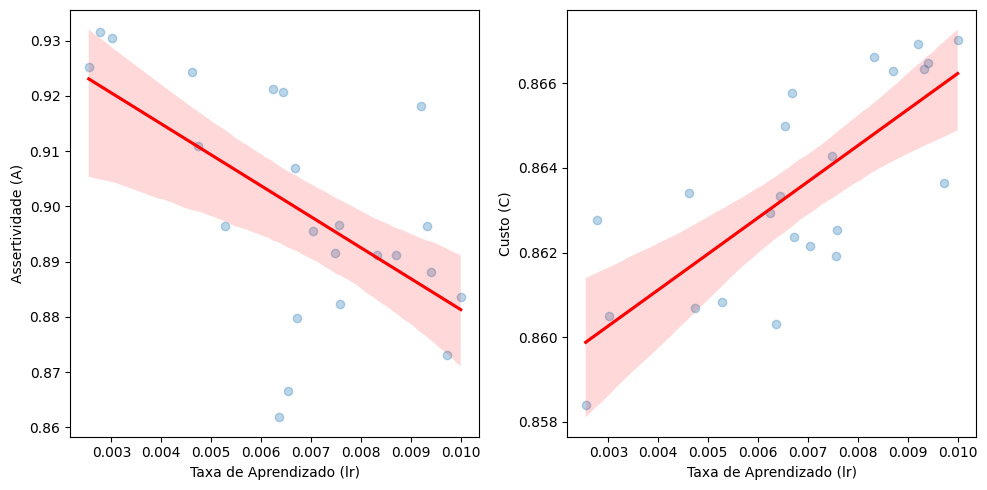

In [16]:
for model in df['model_name'].unique():
    
    subset = df[df['model_name'] == model]
    #print(subset)
    corr_A = subset['lr'].corr(subset['A'])
    corr_C = subset['lr'].corr(subset['C'])
    
    print(f"Modelo: {model}")
    print(f"Correlação (lr vs A): {corr_A:.2f}")
    print(f"Correlação (lr vs C): {corr_C:.2f}")
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    sns.regplot(data=subset, x='lr', y='A', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.xlabel("Taxa de Aprendizado (lr)")
    plt.ylabel("Assertividade (A)")
    
    plt.subplot(1, 2, 2)
    sns.regplot(data=subset, x='lr', y='C', scatter_kws={'alpha': 0.3}, line_kws={'color':'red'})
    plt.xlabel("Taxa de Aprendizado (lr)")
    plt.ylabel("Custo (C)")
    
    plt.tight_layout()
    plt.show()

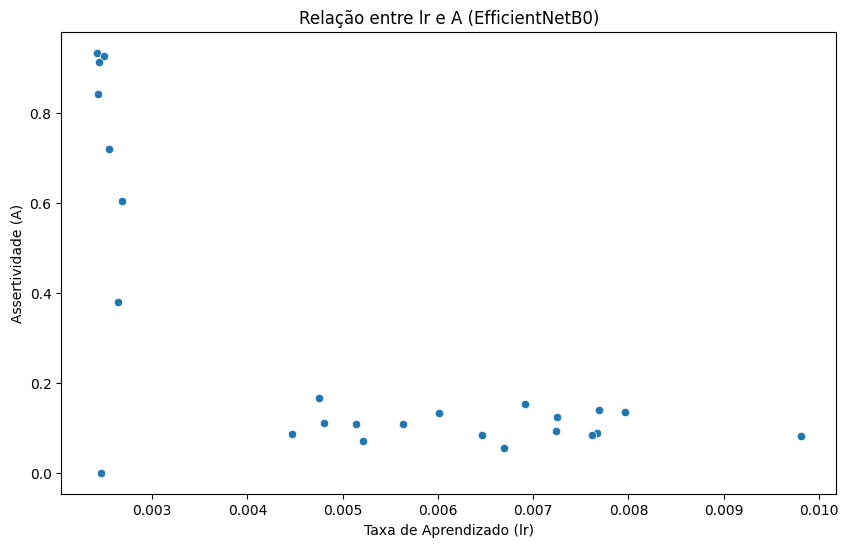

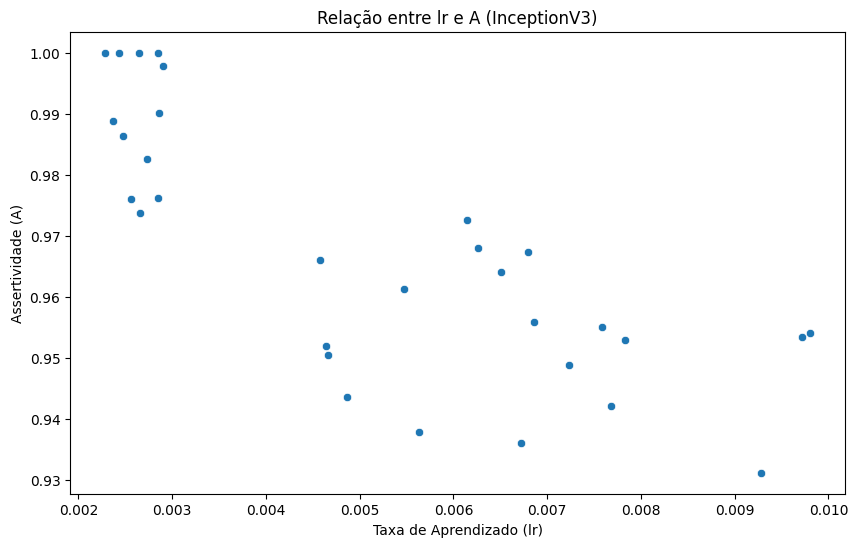

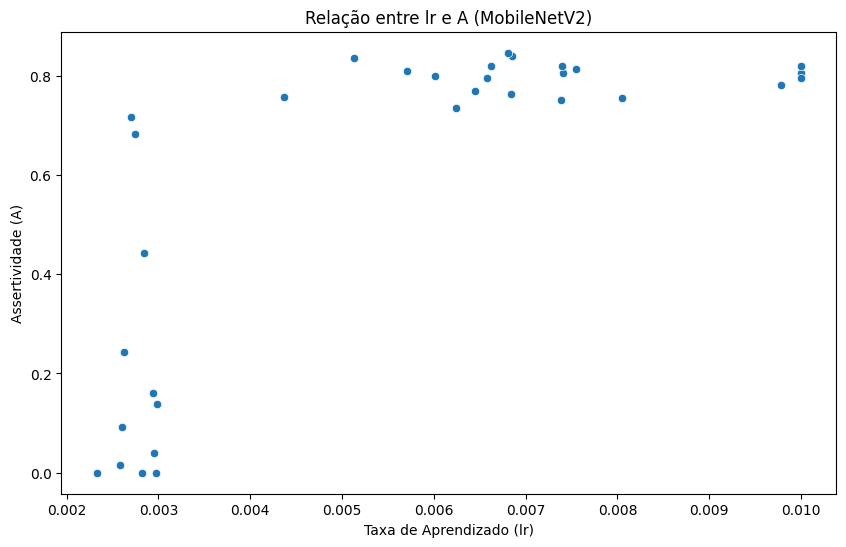

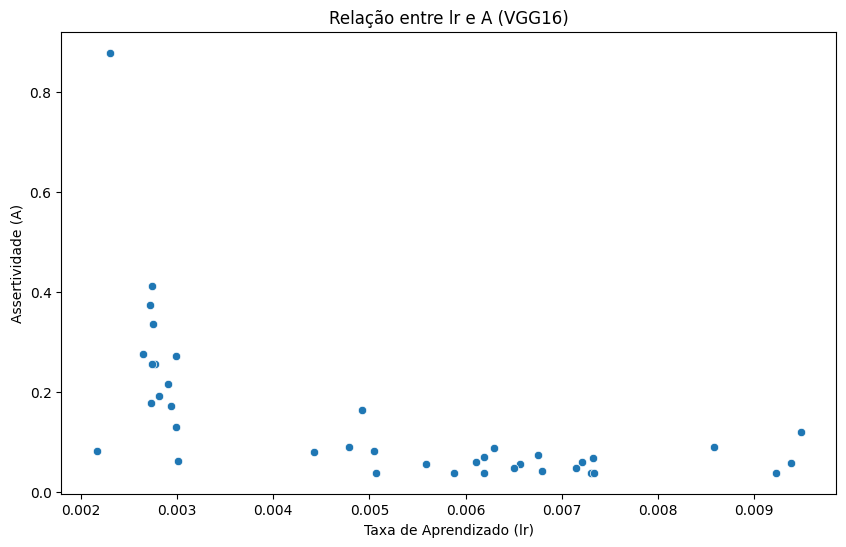

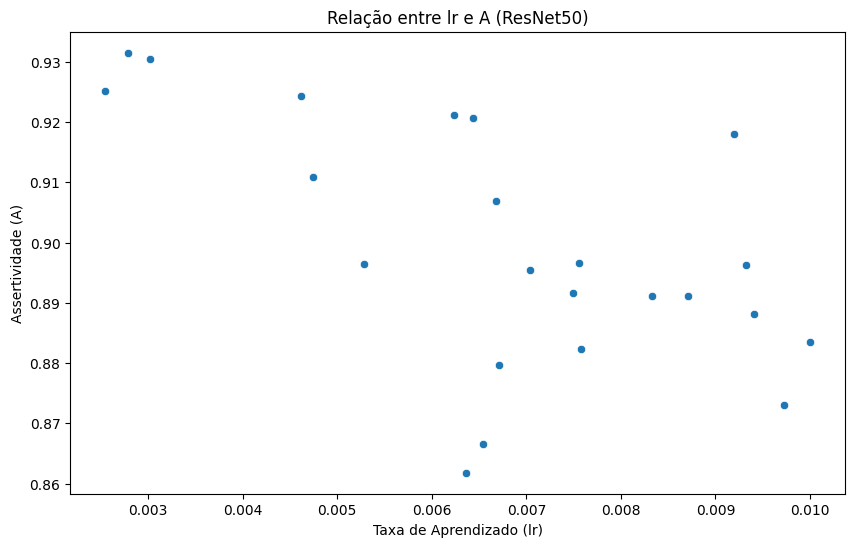

In [18]:
for model in df['model_name'].unique():
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df[df['model_name'] == model], x='lr', y='A')
    plt.xlabel("Taxa de Aprendizado (lr)")
    plt.ylabel("Assertividade (A)")
    plt.title(f"Relação entre lr e A ({model})")
    plt.show()